## QWEN 모델 파인튜닝

대화 학습 데이터셋 및 추론함수 정의

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.optim import AdamW

conversation_data = [
    {"question": "안녕", "answer": "안녕, 나는 LLM 이야. 너는 누구야?"},
    {"question": "너 뭐 할 수 있어?", "answer": "나는 다양한 질문에 답할 수 있어."},
    {"question": "날씨 어때?", "answer": "날씨는 내가 있는 곳에서는 확인할 수 없어."},
    {"question": "몇 살이야?", "answer": "나는 나이가 없지만, 최신 정보를 제공하려 노력해."},
    {"question": "너 좋아하는 건 뭐야?", "answer": "나는 데이터를 분석하고 정보를 제공하는 걸 좋아해."},
]

model_id = "Qwen/Qwen2.5-0.5B-Instruct" # https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct

def gen_model(question_text): # 추론 함수
    messages = [{"role": "user", "content": question_text}] # refer to QuickStart for more details on the message format of Qwen2.5-0.5B-Instruct
    prompt = tokenizer.apply_chat_template(
        messages, 
        tokenize=False,                 # 토크나이저가 프롬프트를 토큰화하지 않고 문자열로 반환하도록 설정
        add_generation_prompt=True      # Ex) <|im_start|>user\nHello<|im_end|><|im_start|>assistant\n
    )

    encoded_input = tokenizer(
        prompt,
        return_tensors="pt",
    )

    input_ids = encoded_input["input_ids"].to(device)
    attention_mask = encoded_input["attention_mask"].to(device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=64, 
            num_beams=1,        # 확률 높은 토큰을 선택할 갯수
            temperature=0.1,    # 창의성을 낮춤.
            top_p=0.9,          # 누적 확률이 top_p 이상인 토큰들만 고려
            do_sample=True,     # True로 설정하면 top_p와 temperature를 적용하여 샘플링 방식으로 토큰을 생성
            pad_token_id=tokenizer.eos_token_id,
        )

    # 생성된 부분만 잘라서 디코딩 (입력 프롬프트 제외)
    generated_ids = output_ids[0][input_ids.shape[1]:]
    decoded_output = tokenizer.decode(generated_ids, skip_special_tokens=True)

    return decoded_output
    

c:\ProgramData\miniconda3\envs\venv_lmm\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


데이터셋 클래스 정의

In [2]:
class ConversationDataset(Dataset):
    def __init__(self, tokenizer, data, max_length=128):
        self.tokenizer = tokenizer
        self.data = data
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Qwen 공식 대화 템플릿 적용
        messages = [
            {"role": "user", "content": item["question"]},
            {"role": "assistant", "content": item["answer"]}
        ]
        
        # 학습용 전체 텍스트 (질문 + 답변)
        full_text = self.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        
        # Loss 계산에서 제외할 질문 부분의 길이를 알기 위해 질문만 따로 템플릿화
        prompt_messages = [{"role": "user", "content": item["question"]}]
        prompt_text = self.tokenizer.apply_chat_template(
            prompt_messages, tokenize=False, add_generation_prompt=True
        )
        
        tokens = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        
        labels = tokens["input_ids"].clone()
        
        # 1. 질문 부분의 토큰 길이를 구해서 그만큼 -100으로 덮어씌움
        prompt_tokens = self.tokenizer(prompt_text, return_tensors="pt")["input_ids"]
        p_len = prompt_tokens.shape[1]
        labels[0, :p_len] = -100
        
        # 2. 패딩 토큰들도 -100으로 덮어씌움
        labels[0, tokens["input_ids"][0] == self.tokenizer.pad_token_id] = -100
        
        return {
            "input_ids": tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "labels": labels.squeeze(0),  
        }


토크나이저, 데이터셋, 모델 및 옵티마이저 준비

In [3]:
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=False)   
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

dataset = ConversationDataset(tokenizer, conversation_data)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True) 

# 모델 준비 및 디바이스 할당
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForCausalLM.from_pretrained(
    model_id,  
    torch_dtype=torch.bfloat16,  
).to(device)

# Optimizer 설정
optimizer = AdamW(model.parameters(), lr=5e-5) 

decoded_output = gen_model("안녕")
print(f"\n모델 학습 전 테스트\nInput: 안녕")
print(f"Output: {decoded_output}")


`torch_dtype` is deprecated! Use `dtype` instead!



모델 학습 전 테스트
Input: 안녕
Output: 안녕하세요! 어떻게 도와드릴까요?


모델 학습

In [4]:
losses = []
epochs = 50 
model.train()
for epoch in range(epochs):
    for batch in dataloader:
        input_ids = batch["input_ids"].long().to(device)  
        attention_mask = batch["attention_mask"].long().to(device)
        labels = batch["labels"].long().to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)        
        
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

# 모델 저장
model_path = "./conversation_qwen2.5_0.5b_model"
tokenizer_path = "./conversation_qwen2.5_0.5b_tokenizer"
model.save_pretrained(model_path)
tokenizer.save_pretrained(tokenizer_path)

print(f"\nModel saved to {model_path}")


Epoch 1, Loss: 3.081472
Epoch 2, Loss: 1.673259
Epoch 3, Loss: 0.165052
Epoch 4, Loss: 0.617464
Epoch 5, Loss: 0.405286
Epoch 6, Loss: 0.141504
Epoch 7, Loss: 0.005717
Epoch 8, Loss: 0.050429
Epoch 9, Loss: 0.006232
Epoch 10, Loss: 0.000245
Epoch 11, Loss: 0.013755
Epoch 12, Loss: 0.000761
Epoch 13, Loss: 0.047818
Epoch 14, Loss: 0.502602
Epoch 15, Loss: 0.000375
Epoch 16, Loss: 0.000761
Epoch 17, Loss: 0.000080
Epoch 18, Loss: 0.000082
Epoch 19, Loss: 0.000046
Epoch 20, Loss: 0.000087
Epoch 21, Loss: 0.000085
Epoch 22, Loss: 0.000035
Epoch 23, Loss: 0.000058
Epoch 24, Loss: 0.000052
Epoch 25, Loss: 0.000029
Epoch 26, Loss: 0.000046
Epoch 27, Loss: 0.000059
Epoch 28, Loss: 0.000055
Epoch 29, Loss: 0.000026
Epoch 30, Loss: 0.000045
Epoch 31, Loss: 0.000025
Epoch 32, Loss: 0.000045
Epoch 33, Loss: 0.000040
Epoch 34, Loss: 0.000025
Epoch 35, Loss: 0.000037
Epoch 36, Loss: 0.000023
Epoch 37, Loss: 0.000037
Epoch 38, Loss: 0.000042
Epoch 39, Loss: 0.000035
Epoch 40, Loss: 0.000023
Epoch 41,

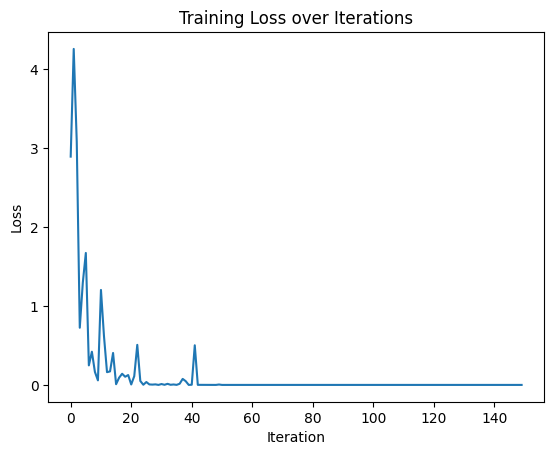

In [5]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.show()

모델 추론 테스트

In [6]:
model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.bfloat16).to(device) # 학습할 때 썼던 bfloat16을 추론할 때도 똑같이 써줘야 에러가 안남.
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)

# 파인튜닝 모델 테스트
model.eval()

inference_text = "안녕"
decoded_output = gen_model(inference_text)
print(f"\n전체 파인튜닝(Full Fine-Tuning) 후 결과\nInput: {inference_text}")
print(f"Output: {decoded_output}")


전체 파인튜닝(Full Fine-Tuning) 후 결과
Input: 안녕
Output: 안녕, 나는 LLM 이야. 너는 누구야?
